In [17]:
# Load Libraries
library(tidyverse)
library(dplyr)      
library(ggplot2)   
library(e1071)      
library(MASS)       
library(lattice)    
library(caret)      

# Load the dataset
df <- read.csv("/kaggle/input/datasets/rddelarosa/e-commerce/EDA_Ecommerce_Assessment.csv")

head(df)

,Customer_ID,Gender,Age,Browsing_Time,Purchase_Amount,Number_of_Items,Discount_Applied,Total_Transactions,Category,Satisfaction_Score
,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>,<int>
1,1,Male,65,46.55,231.81,6,17,16,Clothing,2
2,2,Female,19,98.80,472.78,8,15,43,Books,4
3,3,Male,23,79.48,338.44,1,28,31,Electronics,1
4,4,Male,45,95.75,37.13,7,43,27,Home & Kitchen,5
5,5,Male,46,33.36,235.53,3,10,33,Books,3
6,6,Female,43,83.39,123.92,9,5,29,Clothing,2


# Unit 1: Univariate Data Analysis

1. Load the dataset and summarize its structure.


In [18]:
# Summarize structure
print("Dataset Structure:")
str(df)

print("Dataset Summary:")
summary(df)

[1] "Dataset Structure:"
'data.frame':	3000 obs. of  10 variables:
 $ Customer_ID       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Gender            : chr  "Male" "Female" "Male" "Male" ...
 $ Age               : int  65 19 23 45 46 43 42 29 22 51 ...
 $ Browsing_Time     : num  46.5 98.8 79.5 95.8 33.4 ...
 $ Purchase_Amount   : num  231.8 472.8 338.4 37.1 235.5 ...
 $ Number_of_Items   : int  6 8 1 7 3 9 6 5 8 8 ...
 $ Discount_Applied  : int  17 15 28 43 10 5 2 13 1 31 ...
 $ Total_Transactions: int  16 43 31 27 33 29 8 33 41 19 ...
 $ Category          : chr  "Clothing" "Books" "Electronics" "Home & Kitchen" ...
 $ Satisfaction_Score: int  2 4 1 5 3 2 1 3 4 5 ...
[1] "Dataset Summary:"


  Customer_ID        Gender               Age        Browsing_Time   
 Min.   :   1.0   Length:3000        Min.   :18.00   Min.   :  1.00  
 1st Qu.: 750.8   Class :character   1st Qu.:31.00   1st Qu.: 29.98  
 Median :1500.5   Mode  :character   Median :44.00   Median : 59.16  
 Mean   :1500.5                      Mean   :43.61   Mean   : 59.87  
 3rd Qu.:2250.2                      3rd Qu.:57.00   3rd Qu.: 89.33  
 Max.   :3000.0                      Max.   :69.00   Max.   :119.95  
 Purchase_Amount  Number_of_Items Discount_Applied Total_Transactions
 Min.   :  5.03   Min.   :1.00    Min.   : 0.00    Min.   : 1.00     
 1st Qu.:128.69   1st Qu.:3.00    1st Qu.:12.00    1st Qu.:12.00     
 Median :245.09   Median :5.00    Median :24.00    Median :24.00     
 Mean   :247.96   Mean   :4.99    Mean   :24.34    Mean   :24.68     
 3rd Qu.:367.20   3rd Qu.:7.00    3rd Qu.:37.00    3rd Qu.:37.00     
 Max.   :499.61   Max.   :9.00    Max.   :49.00    Max.   :49.00     
   Category         


2. Create histograms and boxplots to visualize the distribution of Purchase_Amount, Number_of_Items, and Satisfaction_Score.


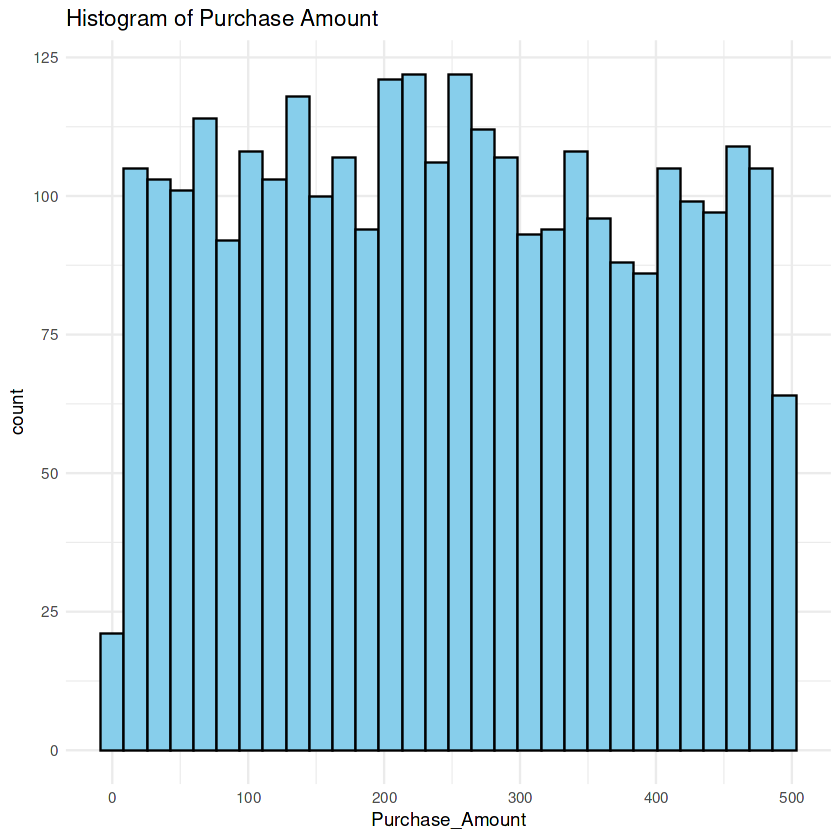

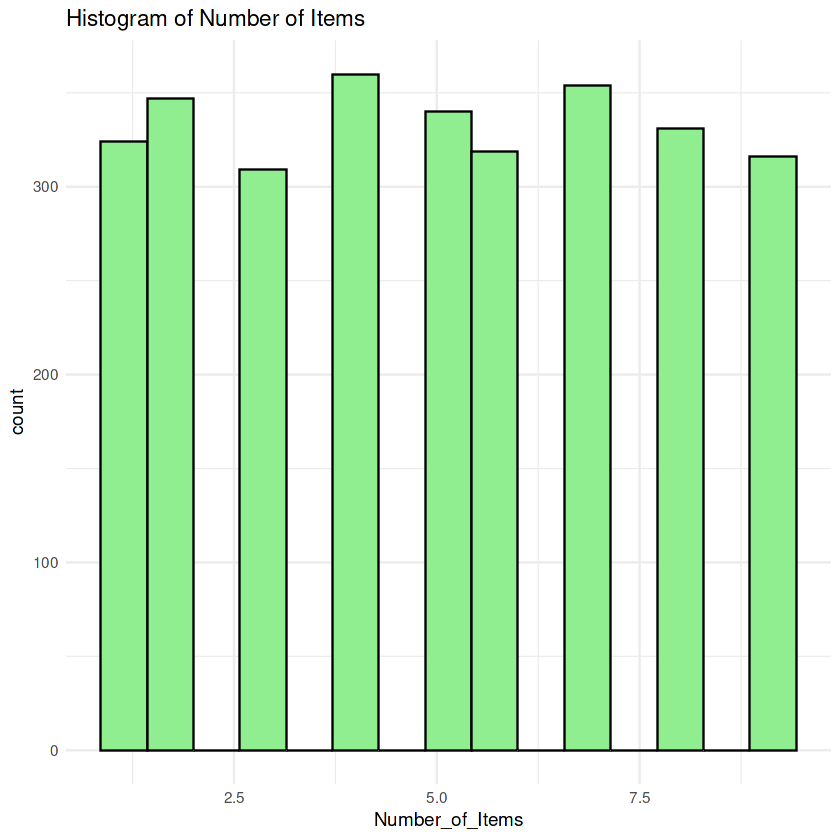

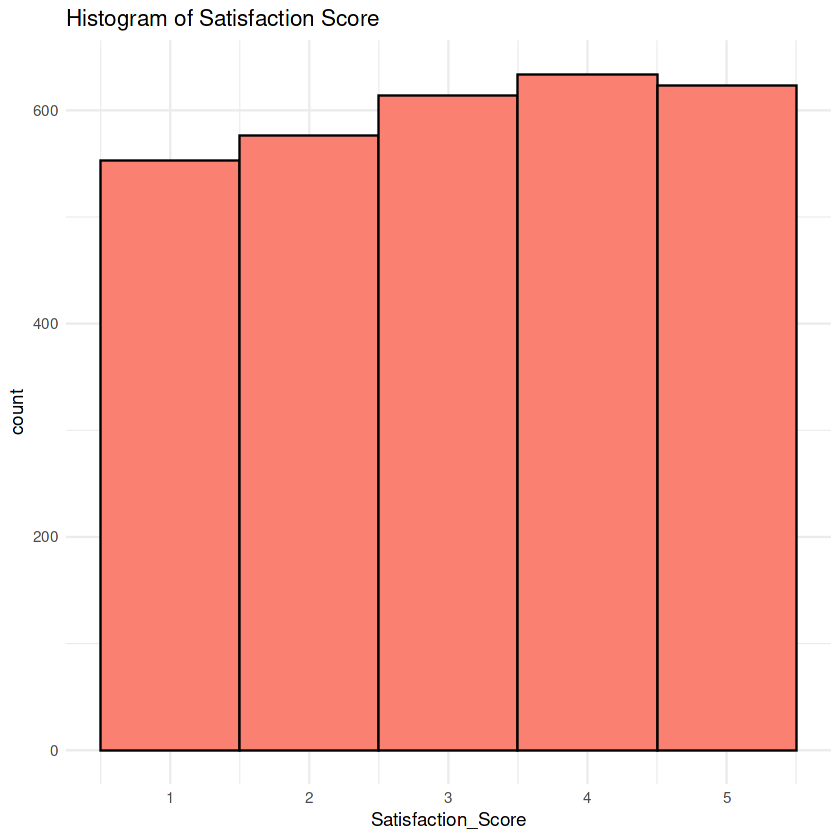

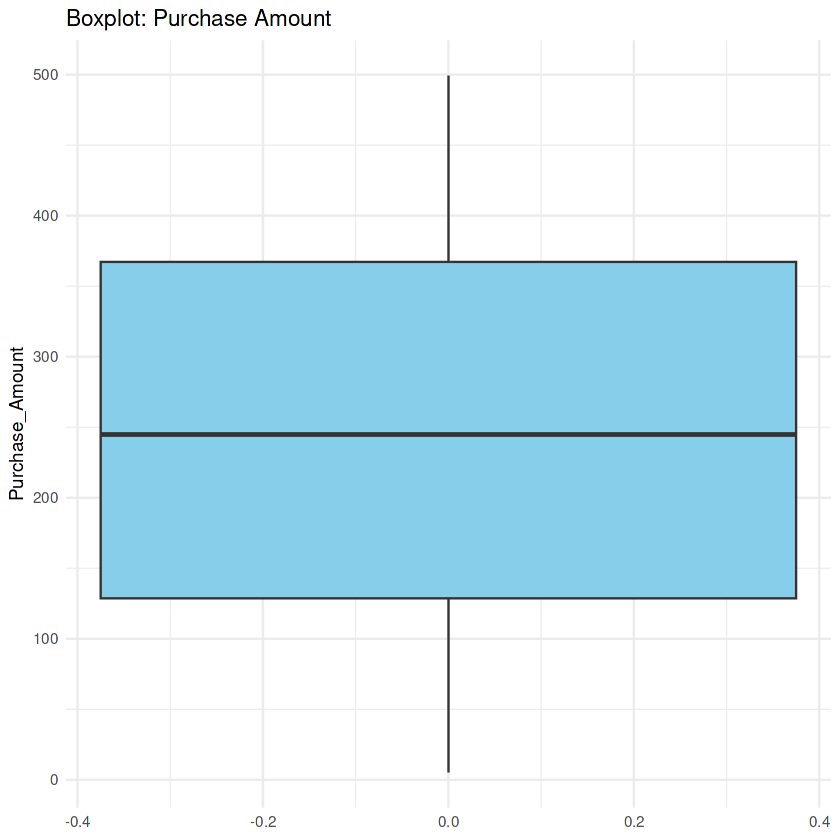

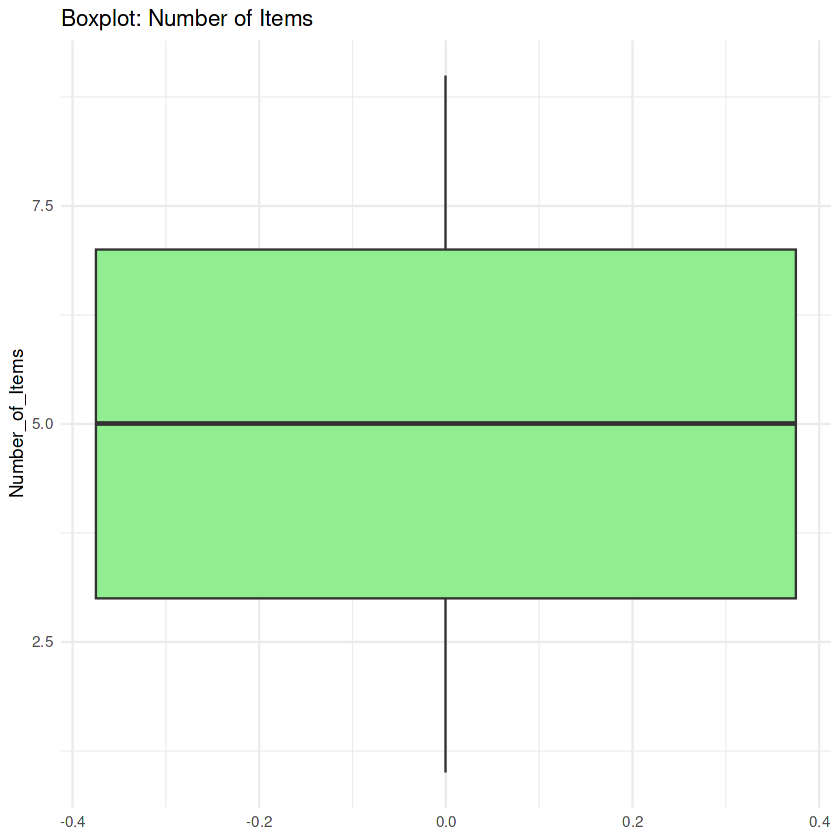

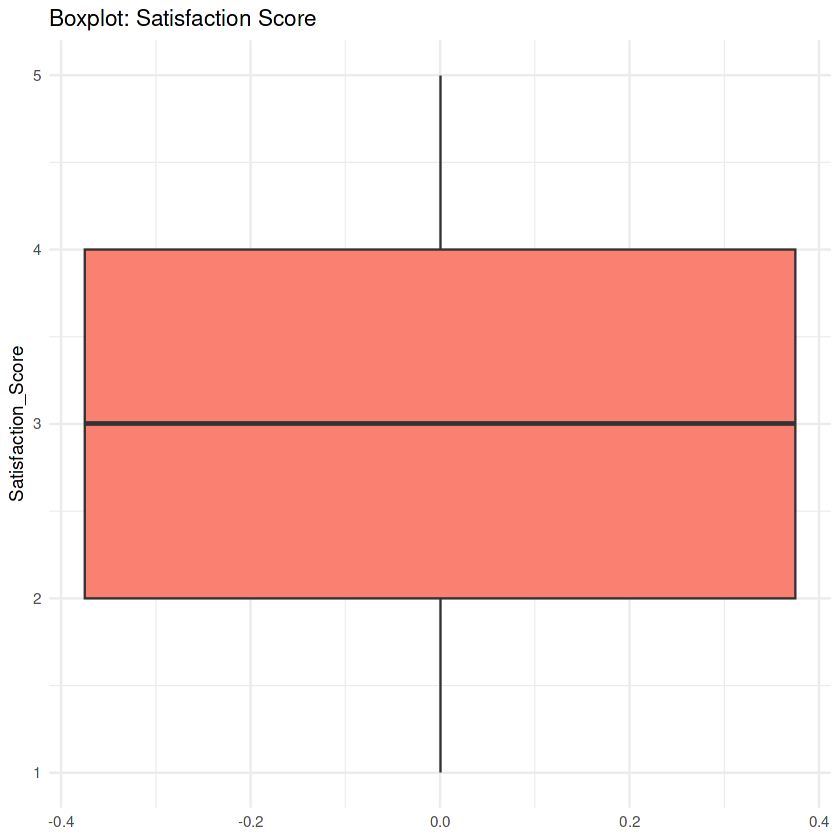

In [19]:
# Histograms
p1 <- ggplot(df, aes(x = Purchase_Amount)) + 
  geom_histogram(fill = "skyblue", color = "black", bins = 30) + 
  theme_minimal() + labs(title = "Histogram of Purchase Amount")

p2 <- ggplot(df, aes(x = Number_of_Items)) + 
  geom_histogram(fill = "lightgreen", color = "black", bins = 15) + 
  theme_minimal() + labs(title = "Histogram of Number of Items")

p3 <- ggplot(df, aes(x = Satisfaction_Score)) + 
  geom_histogram(fill = "salmon", color = "black", bins = 5) + 
  theme_minimal() + labs(title = "Histogram of Satisfaction Score")

print(p1); print(p2); print(p3)

# Boxplots
b1 <- ggplot(df, aes(y = Purchase_Amount)) + 
  geom_boxplot(fill = "skyblue") + theme_minimal() + labs(title = "Boxplot: Purchase Amount")

b2 <- ggplot(df, aes(y = Number_of_Items)) + 
  geom_boxplot(fill = "lightgreen") + theme_minimal() + labs(title = "Boxplot: Number of Items")

b3 <- ggplot(df, aes(y = Satisfaction_Score)) + 
  geom_boxplot(fill = "salmon") + theme_minimal() + labs(title = "Boxplot: Satisfaction Score")

print(b1); print(b2); print(b3)


3. Compute measures of central tendency (mean, median, mode) and spread (variance, standard deviation, IQR) for Purchase_Amount.


In [20]:
# Mode function
get_mode <- function(x) {
  ux <- unique(na.omit(x))
  ux[which.max(tabulate(match(x, ux)))]
}

# Compute statistics
pa_mean <- mean(df$Purchase_Amount, na.rm = TRUE)
pa_median <- median(df$Purchase_Amount, na.rm = TRUE)
pa_mode <- get_mode(df$Purchase_Amount)
pa_var <- var(df$Purchase_Amount, na.rm = TRUE)
pa_sd <- sd(df$Purchase_Amount, na.rm = TRUE)
pa_iqr <- IQR(df$Purchase_Amount, na.rm = TRUE)

cat("--- Purchase Amount Statistics ---\n")
cat("Mean:", pa_mean, "\nMedian:", pa_median, "\nMode:", pa_mode, "\n")
cat("Variance:", pa_var, "\nStd Dev:", pa_sd, "\nIQR:", pa_iqr, "\n")

--- Purchase Amount Statistics ---
Mean: 247.9625 
Median: 245.09 
Mode: 29.33 
Variance: 19845.99 
Std Dev: 140.8758 
IQR: 238.505 



4. Compare the distribution of Browsing_Time and Purchase_Amount across different Gender groups using density plots.



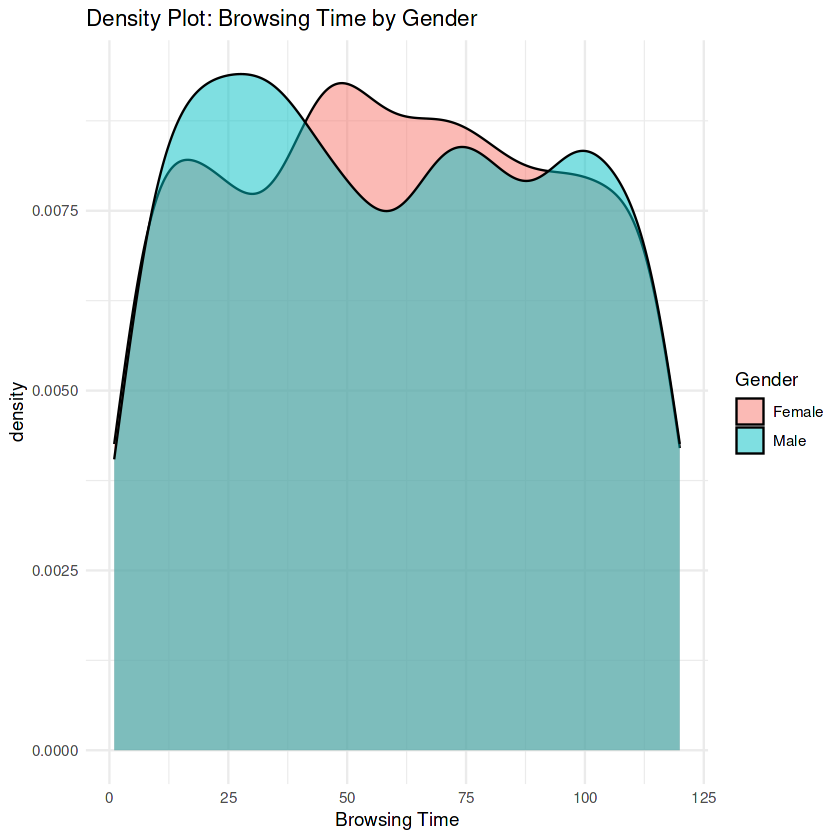

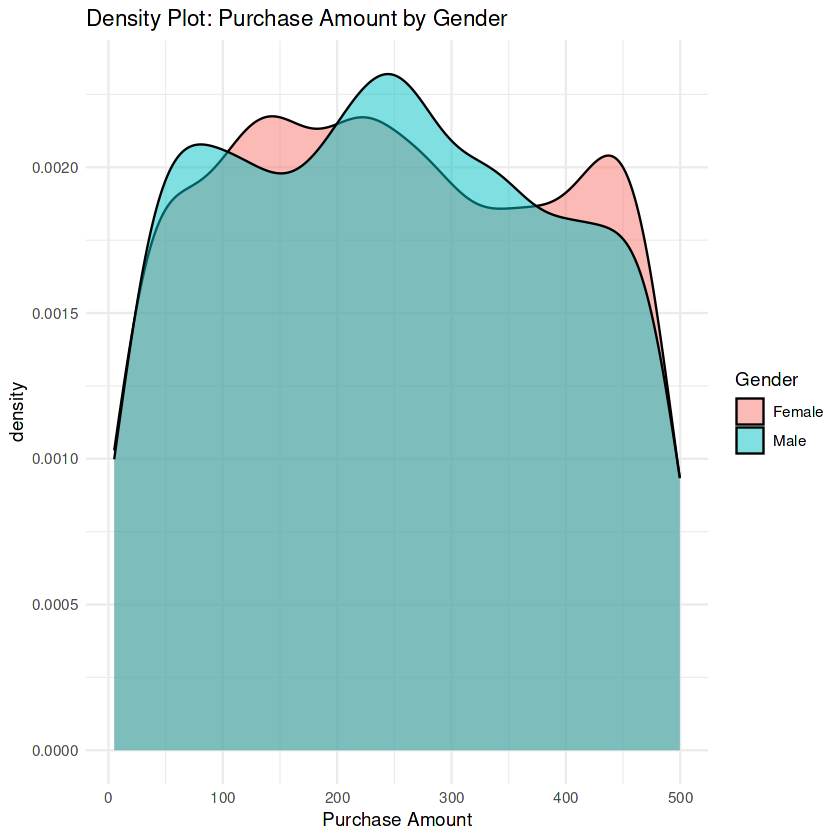

In [21]:
# Browsing Time by Gender
ggplot(df, aes(x = Browsing_Time, fill = Gender)) + 
  geom_density(alpha = 0.5) + theme_minimal() +
  labs(title = "Density Plot: Browsing Time by Gender", x = "Browsing Time")

# Purchase Amount by Gender
ggplot(df, aes(x = Purchase_Amount, fill = Gender)) + 
  geom_density(alpha = 0.5) + theme_minimal() +
  labs(title = "Density Plot: Purchase Amount by Gender", x = "Purchase Amount")

5. Apply a logarithmic or square root transformation on Browsing_Time and evaluate changes in skewness.



In [22]:
# Original Skewness
skew_original <- skewness(df$Browsing_Time, na.rm = TRUE)

# Apply Transformations
df$Log_Browsing <- log(df$Browsing_Time + 1) # +1 prevents log(0) issues
df$Sqrt_Browsing <- sqrt(df$Browsing_Time)

skew_log <- skewness(df$Log_Browsing, na.rm = TRUE)
skew_sqrt <- skewness(df$Sqrt_Browsing, na.rm = TRUE)

cat("Skewness Original:", skew_original, "\n")
cat("Skewness Log Transformed:", skew_log, "\n")
cat("Skewness Sqrt Transformed:", skew_sqrt, "\n")

Skewness Original: 0.03861558 
Skewness Log Transformed: -1.218373 
Skewness Sqrt Transformed: -0.4768351 


6. Fit a simple linear regression model predicting Purchase_Amount based on Browsing_Time. Interpret the results.


In [34]:
# Fit linear model
slr_model <- lm(Purchase_Amount ~ Browsing_Time, data = df)
print(summary(slr_model))


Call:
lm(formula = Purchase_Amount ~ Browsing_Time, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-244.867 -120.473   -2.946  118.246  254.069 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   252.65596    5.17524  48.820   <2e-16 ***
Browsing_Time  -0.07839    0.07501  -1.045    0.296    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2998 degrees of freedom
Multiple R-squared:  0.0003642,	Adjusted R-squared:  3.075e-05 
F-statistic: 1.092 on 1 and 2998 DF,  p-value: 0.2961



Report: Look at the Pr(>|t|) value for Browsing_Time. If it is $< 0.05$, Browsing Time significantly predicts Purchase Amount. Look at the Adjusted R-squared to explain how much variance in Purchase Amount is explained by Browsing Time.


7. Use ggplot2 (or equivalent) to create scatter plots and regression lines.

`geom_smooth()` using formula = 'y ~ x'


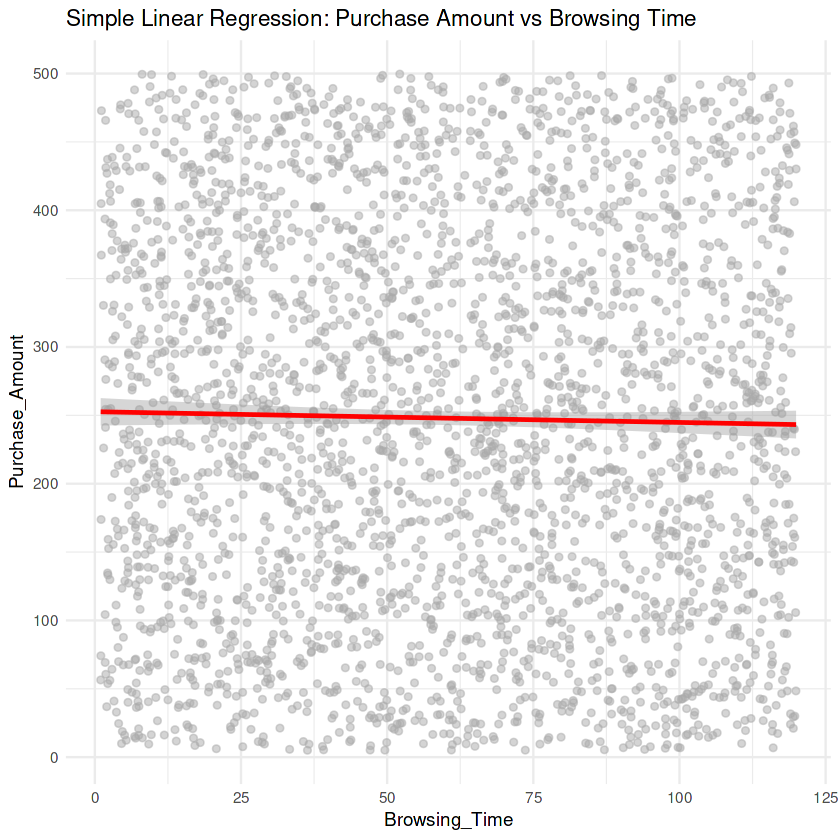

In [32]:
# Scatter plot with regression line
ggplot(df, aes(x = Browsing_Time, y = Purchase_Amount)) +
  geom_point(alpha = 0.5, color = "darkgray") +
  geom_smooth(method = "lm", color = "red", se = TRUE) +
  theme_minimal() +
  labs(title = "Simple Linear Regression: Purchase Amount vs Browsing Time")

### Unit 2: Bivariate Data Analysis
8. Create scatter plots to explore the relationship between Purchase_Amount and Number_of_Items.

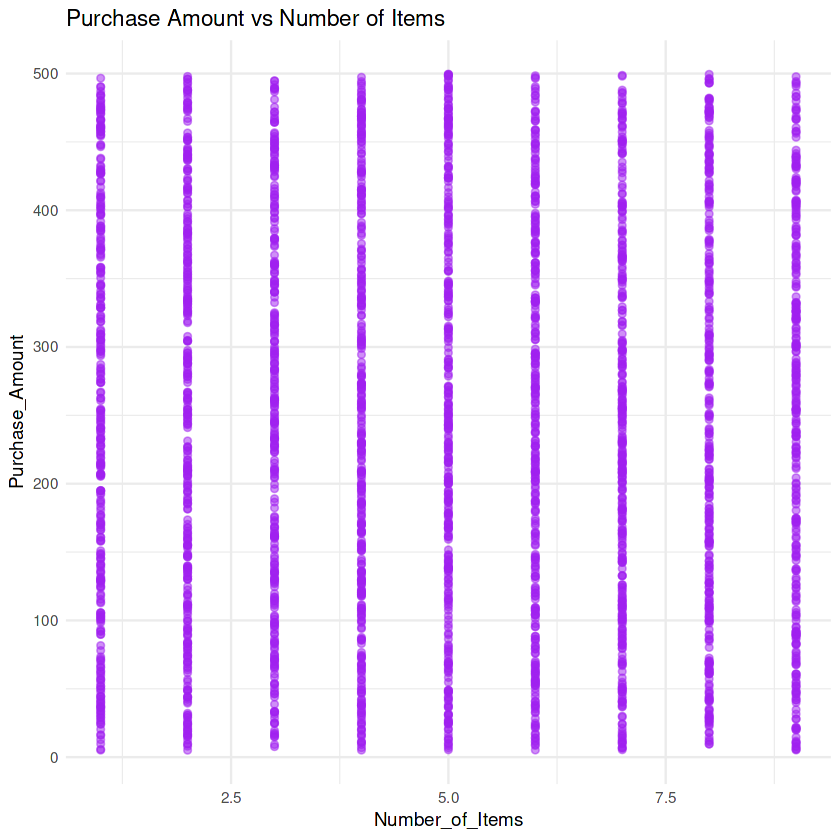

In [24]:
ggplot(df, aes(x = Number_of_Items, y = Purchase_Amount)) +
  geom_point(alpha = 0.5, color = "purple") +
  theme_minimal() +
  labs(title = "Purchase Amount vs Number of Items")

9. Fit a polynomial regression model for Purchase_Amount and Browsing_Time and compare it with a simple linear model.

In [35]:
# Fit polynomial model
poly_model <- lm(Purchase_Amount ~ poly(Browsing_Time, 2), data = df)
print(summary(poly_model))

# Compare models using ANOVA
cat("\n--- ANOVA Comparison: Linear vs Polynomial ---\n")
print(anova(slr_model, poly_model))


Call:
lm(formula = Purchase_Amount ~ poly(Browsing_Time, 2), data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-245.47 -120.41   -3.49  118.25  255.85 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)              247.963      2.572  96.397   <2e-16 ***
poly(Browsing_Time, 2)1 -147.227    140.892  -1.045    0.296    
poly(Browsing_Time, 2)2  -68.129    140.892  -0.484    0.629    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2997 degrees of freedom
Multiple R-squared:  0.0004422,	Adjusted R-squared:  -0.0002249 
F-statistic: 0.6629 on 2 and 2997 DF,  p-value: 0.5154


--- ANOVA Comparison: Linear vs Polynomial ---
Analysis of Variance Table

Model 1: Purchase_Amount ~ Browsing_Time
Model 2: Purchase_Amount ~ poly(Browsing_Time, 2)
  Res.Df      RSS Df Sum of Sq      F Pr(>F)
1   2998 59496437                           
2   2997 59491795  1    4641.6 0.2338 0.6287


The anova test checks if the polynomial model is a significant improvement over the linear model. If the p-value is $< 0.05$, the relationship has a significant curve.

10. Apply LOESS (Locally Estimated Scatterplot Smoothing) to Purchase_Amount vs. Browsing_Time and visualize the results.

`geom_smooth()` using formula = 'y ~ x'


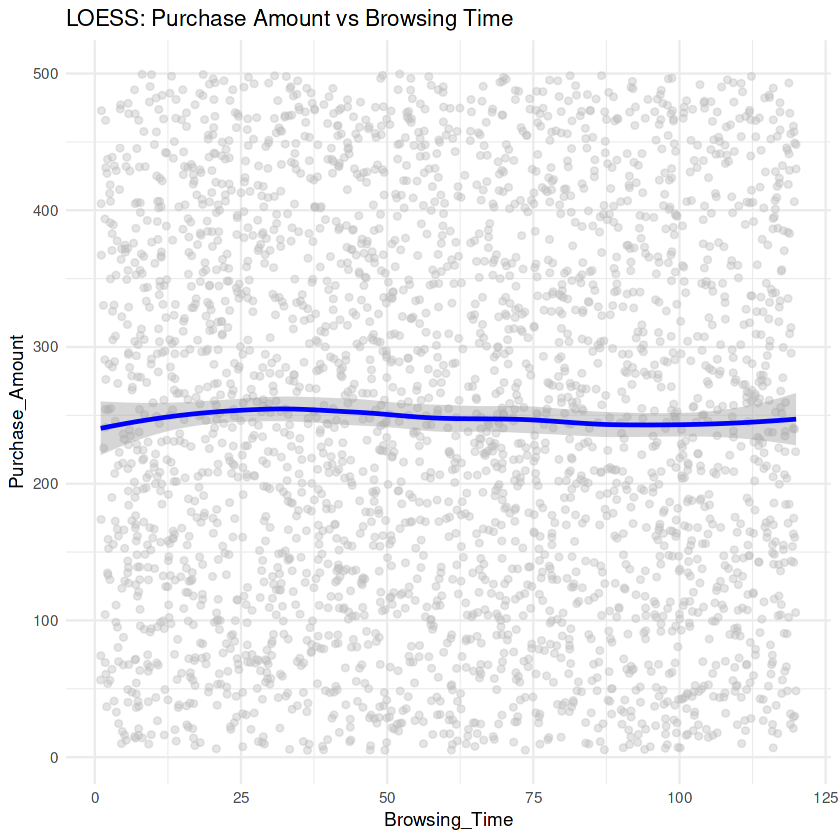

In [26]:
ggplot(df, aes(x = Browsing_Time, y = Purchase_Amount)) +
  geom_point(alpha = 0.4, color = "gray") +
  geom_smooth(method = "loess", color = "blue", se = TRUE) +
  theme_minimal() +
  labs(title = "LOESS: Purchase Amount vs Browsing Time")

11. Compare robust regression methods (Huber or Tukey regression) with ordinary least squares (OLS).

OLS Coefficients:
  (Intercept) Browsing_Time 
 252.65595638   -0.07839485 

Robust Coefficients:
  (Intercept) Browsing_Time 
 252.64618558   -0.08026744 


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


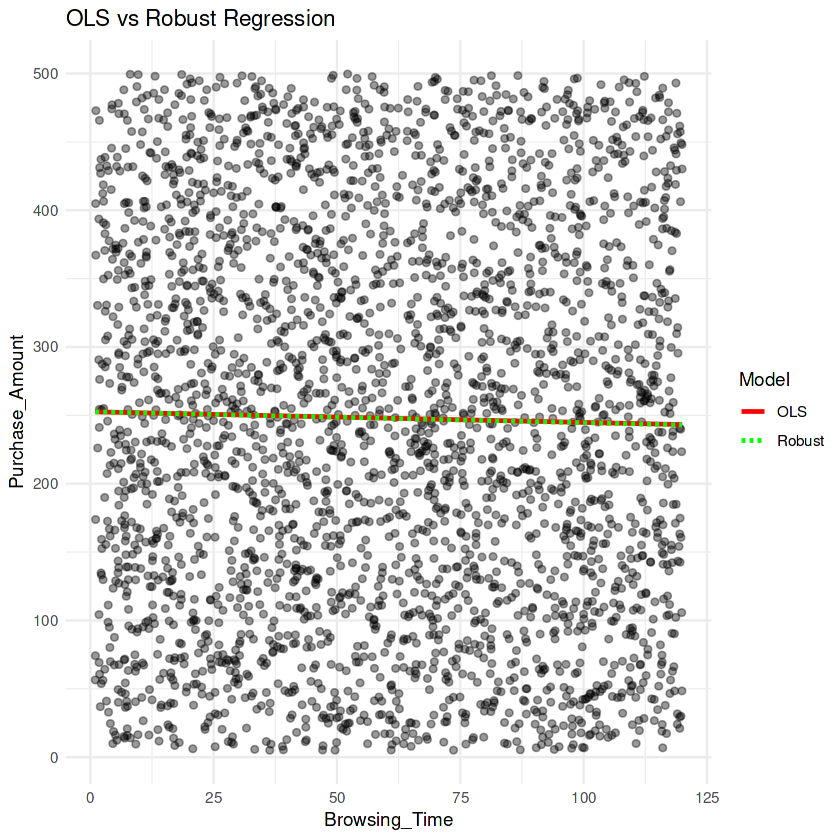

In [27]:
# Fit Robust Regression (Huber's M-estimation)
robust_model <- rlm(Purchase_Amount ~ Browsing_Time, data = df)

# Compare Coefficients
cat("OLS Coefficients:\n"); print(coef(slr_model))
cat("\nRobust Coefficients:\n"); print(coef(robust_model))

# Visualize both
ggplot(df, aes(x = Browsing_Time, y = Purchase_Amount)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", color = "red", se = FALSE, aes(linetype = "OLS")) +
  geom_smooth(method = "rlm", color = "green", se = FALSE, aes(linetype = "Robust")) +
  scale_linetype_manual(name="Model", values=c("OLS"="solid", "Robust"="dashed")) +
  theme_minimal() +
  labs(title = "OLS vs Robust Regression")

# Unit 3: Trivariate/Hypervariate Data Analysis
12. Explore interaction effects between Browsing_Time and Category on Purchase_Amount using interaction plots.

`geom_smooth()` using formula = 'y ~ x'


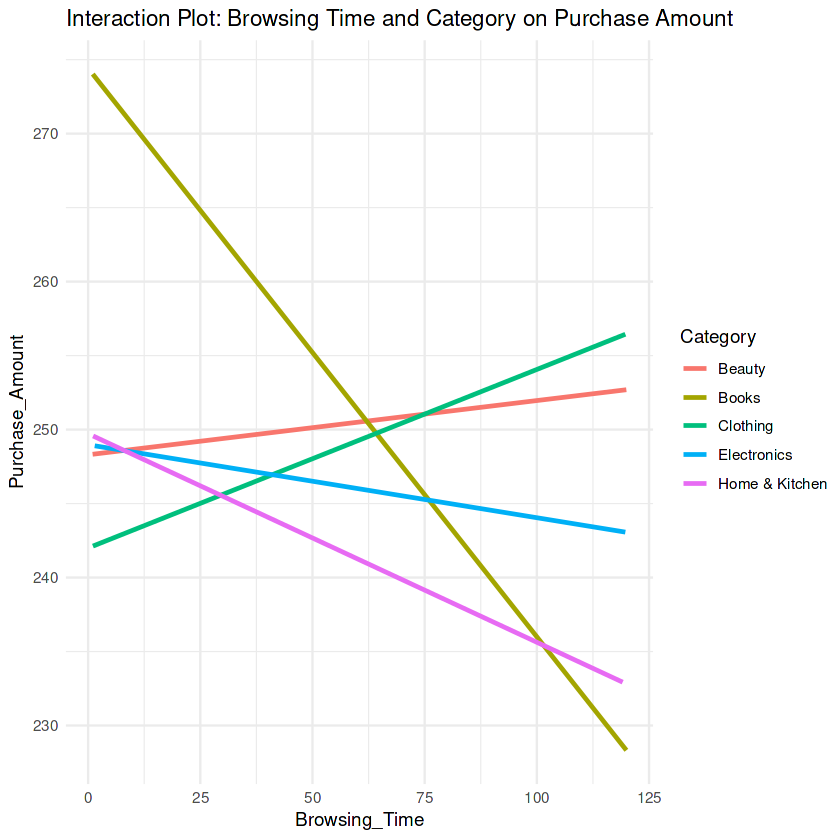

In [36]:
ggplot(df, aes(x = Browsing_Time, y = Purchase_Amount, color = Category)) +
  geom_smooth(method = "lm", se = FALSE) +
  theme_minimal() +
  labs(title = "Interaction Plot: Browsing Time and Category on Purchase Amount")

13. Create coplots of Purchase_Amount against Browsing_Time for different levels of Category.

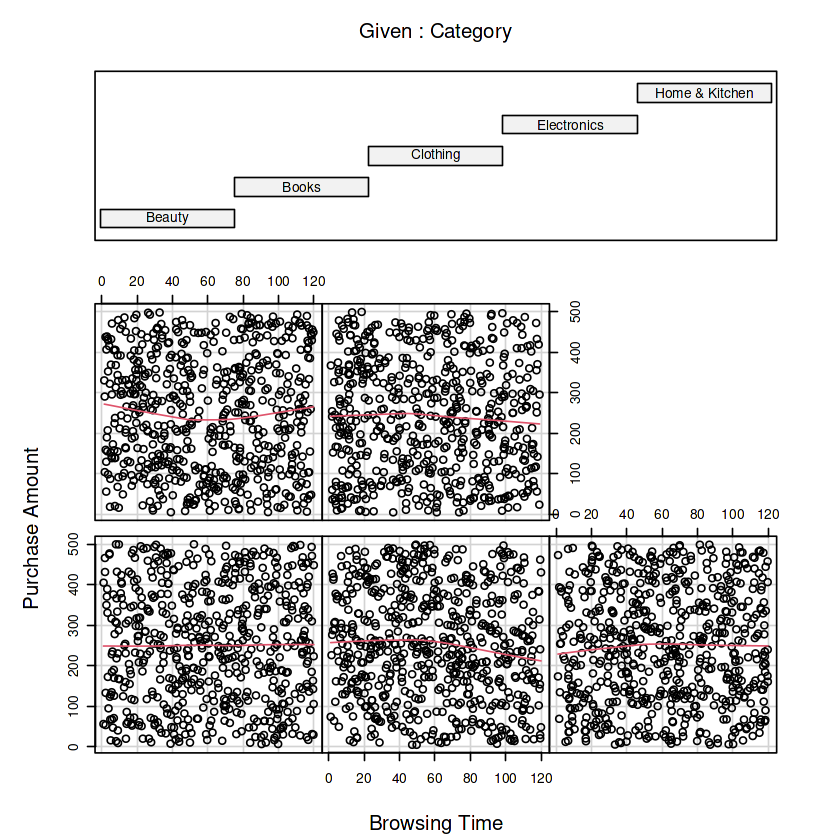

In [37]:
# Coplot of Purchase Amount against Browsing Time given Category
coplot(Purchase_Amount ~ Browsing_Time | Category, data = df,
       panel = function(x, y, ...) {
         panel.smooth(x, y, span = 0.8, ...)
       },
       main = "Coplot: Purchase Amount vs Browsing Time given Category",
       xlab = "Browsing Time", ylab = "Purchase Amount")

14. Use level plots or contour plots to visualize relationships between Browsing_Time, Number_of_Items, and Purchase_Amount.

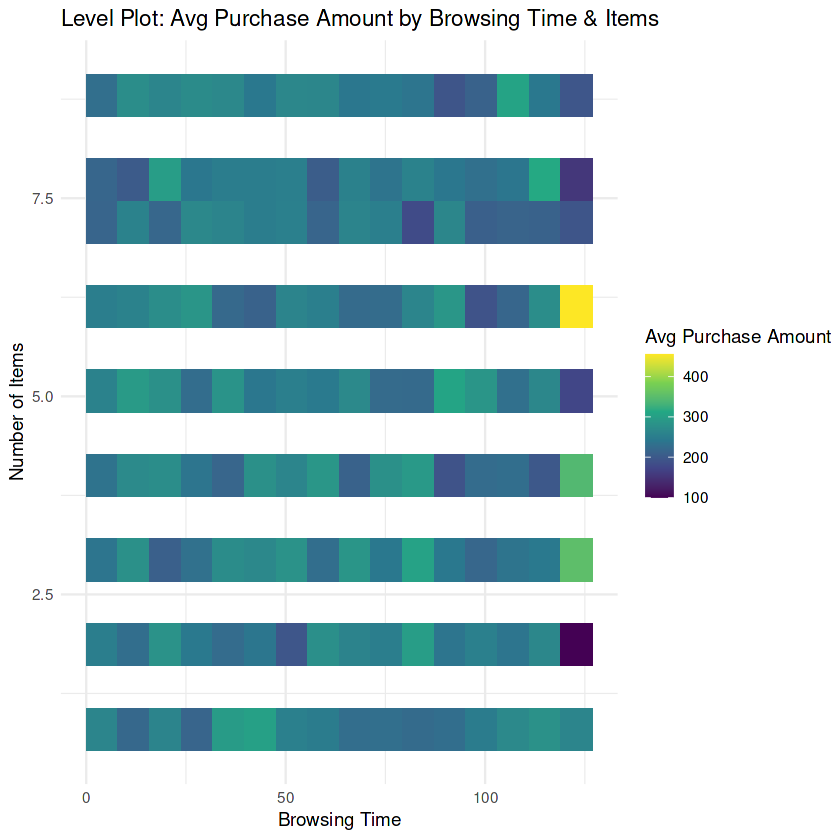

In [39]:
ggplot(df, aes(x = Browsing_Time, y = Number_of_Items, z = Purchase_Amount)) +
  stat_summary_2d(fun = mean, bins = 15) +
  scale_fill_viridis_c(name = "Avg Purchase Amount") +
  theme_minimal() +
  labs(title = "Level Plot: Avg Purchase Amount by Browsing Time & Items",
       x = "Browsing Time", y = "Number of Items")

15. Perform multiple regression with Purchase_Amount as the dependent variable and Browsing_Time, Number_of_Items, and Satisfaction_Score as predictors. Perform model selection and assess variable importance.


In [40]:
# Fit the full multiple regression model
mult_model <- lm(Purchase_Amount ~ Browsing_Time + Number_of_Items + Satisfaction_Score, data = df)
print(summary(mult_model))

cat("\n--- Stepwise Model Selection ---\n")
step_model <- step(mult_model, direction = "both")
print(summary(step_model))

cat("\n--- Variable Importance (t-statistic based) ---\n")
var_imp <- varImp(step_model, scale = TRUE)
print(var_imp)


Call:
lm(formula = Purchase_Amount ~ Browsing_Time + Number_of_Items + 
    Satisfaction_Score, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-250.668 -120.856   -2.846  118.899  255.664 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        261.34993    9.24929  28.256   <2e-16 ***
Browsing_Time       -0.07954    0.07504  -1.060    0.289    
Number_of_Items     -0.78321    1.00497  -0.779    0.436    
Satisfaction_Score  -1.53871    1.83444  -0.839    0.402    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2996 degrees of freedom
Multiple R-squared:  0.0007932,	Adjusted R-squared:  -0.0002073 
F-statistic: 0.7928 on 3 and 2996 DF,  p-value: 0.4978


--- Stepwise Model Selection ---
Start:  AIC=29691.89
Purchase_Amount ~ Browsing_Time + Number_of_Items + Satisfaction_Score

                     Df Sum of Sq      RSS   AIC
- Number_of_Items     1     12056 59482958 29